# Árvores II - Tarefa 2

### 1. Carregar as bases

Vamos carregar as bases lidas na tarefa passada. Se você salvou essas bases em arquivo texto, basta fazer a leitura com o comando ```pd.read_csv``` das seguintes bases:

- X_train
- Y_train
- X_test
- Y_test

Não se esqueça de considerar a leitura dos índices dos arquivos no ```read_csv()```!

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [4]:
X_train = pd.read_csv('X_train.txt', sep=r'\s+', header=None)
y_train = pd.read_csv('y_train.txt', sep=r'\s+', header=None)
X_test = pd.read_csv('X_test.txt', sep=r'\s+', header=None)
y_test = pd.read_csv('y_test.txt', sep=r'\s+', header=None)

### 2. Divisão da base em Treino, Validação e Teste

A base já se encontra dividida em Treino e Validação. O que vamos fazer então é extrair uma base de Validação da base de Treino.

Extraia 25% da base de treino como base de validação.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=2360873)

print(f"Novo treino: {X_train.shape}, Validação: {X_valid.shape}")

Novo treino: (5881, 561), Validação: (1471, 561)


### 3. Melhores 3 variáveis

Rode uma árvore com profundidade máxima igual a 4 para prever a atividade humana com todas as variáveis.
Observe a importância das variáveis e considere as 3 variáveis com maior importância para os próximos passos.
Dica: utilize o atributo ```clf.feature_importances_``` da árvore treinada.

In [6]:
clf_completa = DecisionTreeClassifier(random_state=2360873)
clf_completa.fit(X_train, y_train)

importancias = clf_completa.feature_importances_
indices_importantes = np.argsort(importancias)[-3:] # Pega os índices das 3 maiores

X_train_top3 = X_train.iloc[:, indices_importantes]
X_valid_top3 = X_valid.iloc[:, indices_importantes]
X_test_top3  = X_test.iloc[:, indices_importantes]

print(f"Índices das 3 melhores variáveis: {indices_importantes}")

Índices das 3 melhores variáveis: [559 265  52]


### 4. Construa uma árvore com as 3 melhores variáveis

Utilizando as três variáveis encontradas acima, construa uma árvore de decisão. Encontre o melhor ```ccp_alpha``` utilizando a base de validação, conforme a estrutura que vimos em aula.

In [7]:
%%time
path = DecisionTreeClassifier(random_state=2360873).cost_complexity_pruning_path(X_train_top3, y_train)
ccp_alphas = path.ccp_alphas

clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=2360873, ccp_alpha=ccp_alpha)
    clf.fit(X_train_top3, y_train)
    clfs.append(clf)

valid_scores = [clf.score(X_valid_top3, y_valid) for clf in clfs]

melhor_acc_valid = max(valid_scores)
melhor_alpha = ccp_alphas[valid_scores.index(melhor_acc_valid)]
melhor_modelo = clfs[valid_scores.index(melhor_acc_valid)]

print(f"Melhor Alpha encontrado na validação: {melhor_alpha}")

Melhor Alpha encontrado na validação: 0.00020060793757845186
CPU times: user 8.01 s, sys: 150 ms, total: 8.16 s
Wall time: 9.27 s


### 5. Avaliação do modelo

Avalie a árvore encontrada no item anterior na base de testes.

Acurácia final na base de teste: 71.02%


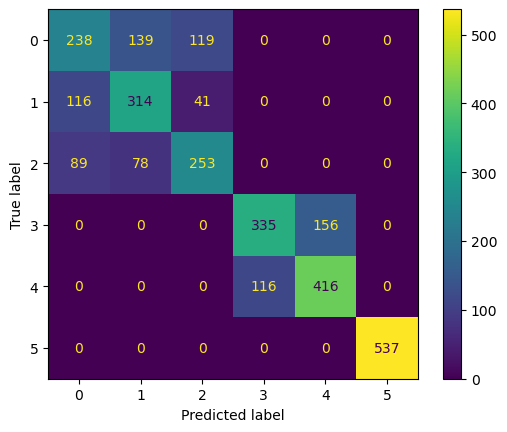

In [8]:
acc_teste = melhor_modelo.score(X_test_top3, y_test)

print(f"Acurácia final na base de teste: {acc_teste:.2%}")

y_pred = melhor_modelo.predict(X_test_top3)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()